### Verify the Dataset

In [1]:
import os

train_path = "dataset/train"

print(os.listdir(train_path))

['Dog', 'Cat']


### Check the number of cat images

In [3]:
cat_folder = "dataset/train/Cat"

print(len(os.listdir(cat_folder)))

8749


### Check dog images

In [4]:
dog_folder = "dataset/train/Dog"

print(len(os.listdir(dog_folder)))

8749


### Check One Image

In [9]:
from PIL import Image

image = Image.open("dataset/train/Cat/300.jpg")

print(image.size)

(500, 357)


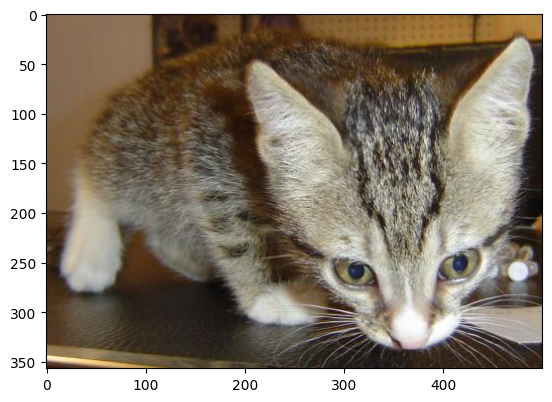

In [11]:
import matplotlib.pyplot as plt

plt.imshow(image)
# plt.axis("off")
plt.show()

# Data Preparation & Transforms

### Import Libraries

In [13]:
# PyTorch
import torch

# Image transforms (Image preprocessing)
from torchvision import transforms

# Load dataset from folders (Reads images and labels automatically)
from torchvision.datasets import ImageFolder

# Create DataLoader (Loads data in batches)
from torch.utils.data import DataLoader

# Display images
import matplotlib.pyplot as plt

### Training Transform

In [14]:
train_transform = transforms.Compose([

    # Resize every image
    transforms.Resize((224, 224)),

    # Randomly flip image horizontally
    transforms.RandomHorizontalFlip(p=0.5),

    # Randomly rotate image
    transforms.RandomRotation(15),

    # Convert PIL image to Tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Validation Transform

In [15]:
val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

### Load Dataset

In [18]:
# Training
train_dataset = ImageFolder(

    root="dataset/train",

    transform=train_transform

)

# Validation
val_dataset = ImageFolder(

    root="dataset/valid",

    transform=val_transform

)


# Testing
test_dataset = ImageFolder(

    root="dataset/test",

    transform=val_transform

)

### Build DataLoader

In [19]:
# Training
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)


# Validation 
val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)



# Testing
test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

### Verify Dataset

In [20]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

17498
3748
3752


In [21]:
print(train_dataset.classes)

['Cat', 'Dog']


### Check Batch Shape

In [22]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


### Visualize Images

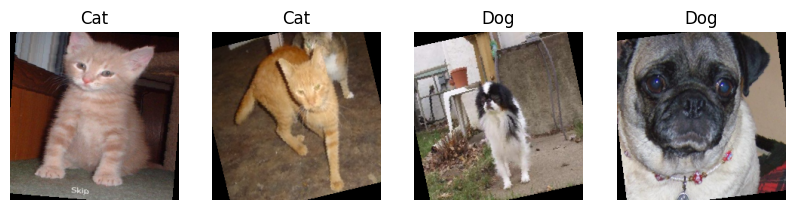

In [26]:
import torch

# Get one batch
images, labels = next(iter(train_loader))

# ImageNet mean and std
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Display first 4 images
plt.figure(figsize=(10, 5))

for i in range(4):

    img = images[i] * std + mean          # Undo normalization
    img = img.permute(1, 2, 0).clamp(0, 1)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

# Complete Code

### Imports

In [27]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from tqdm.auto import tqdm

### Configuration

In [28]:
TRAIN_DIR = "dataset/train"
VAL_DIR = "dataset/valid"
TEST_DIR = "dataset/test"

BATCH_SIZE = 32
IMAGE_SIZE = 224

EPOCHS = 20
LEARNING_RATE = 0.001

NUM_CLASSES = 2

CLASS_NAMES = ["Cat", "Dog"]

MODEL_PATH = "best_model.pth"

### Device

In [29]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


### Transforms

In [30]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

### Dataset

In [31]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

### DataLoader

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### Visualize Training Images

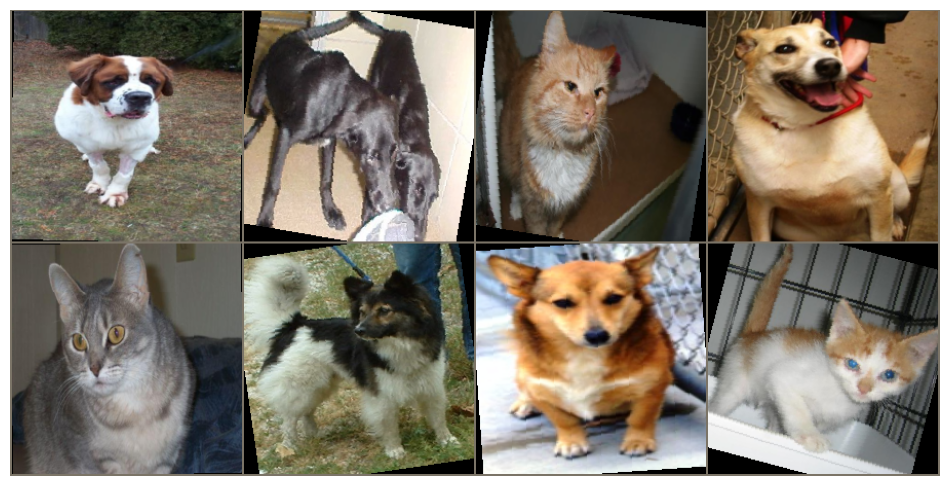

Labels:
Image 1: Dog
Image 2: Dog
Image 3: Cat
Image 4: Dog
Image 5: Cat
Image 6: Dog
Image 7: Dog
Image 8: Cat


In [33]:
import matplotlib.pyplot as plt
import torchvision


def imshow(img):
    """
    Display a batch of images.
    """

    # Convert tensor to numpy
    img = img.numpy().transpose((1, 2, 0))

    # Un-normalize ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean

    img = np.clip(img, 0, 1)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Get one batch
images, labels = next(iter(train_loader))

# Create image grid
grid = torchvision.utils.make_grid(images[:8], nrow=4)

imshow(grid)

print("Labels:")

for i in range(8):
    print(f"Image {i+1}: {CLASS_NAMES[labels[i]]}")

### Dataset Information

In [34]:
print("=" * 50)

print("Dataset Information")

print("=" * 50)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print()

print(f"Classes : {train_dataset.classes}")

print()

print(f"Class to Index Mapping:")

print(train_dataset.class_to_idx)

print("=" * 50)

Dataset Information
Training Images   : 17498
Validation Images : 3748
Test Images       : 3752

Classes : ['Cat', 'Dog']

Class to Index Mapping:
{'Cat': 0, 'Dog': 1}


### Build ResNet18

In [35]:
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

# Download pretrained ImageNet weights
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Freeze Feature Extractor

In [36]:
for parameter in model.parameters():

    parameter.requires_grad = False

print("Feature extractor frozen.")

Feature extractor frozen.


### Replace Final Layer

In [37]:
import torch.nn as nn

num_features = model.fc.in_features

model.fc = nn.Linear(

    in_features=num_features,

    out_features=NUM_CLASSES

)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


### Verify Trainable Parameters

In [38]:
trainable = 0

frozen = 0

print("=" * 50)

for name, parameter in model.named_parameters():

    if parameter.requires_grad:

        print(f"Trainable : {name}")

        trainable += parameter.numel()

    else:

        frozen += parameter.numel()

print("=" * 50)

print(f"Trainable Parameters : {trainable:,}")

print(f"Frozen Parameters    : {frozen:,}")

print(f"Total Parameters     : {trainable + frozen:,}")

Trainable : fc.weight
Trainable : fc.bias
Trainable Parameters : 1,026
Frozen Parameters    : 11,176,512
Total Parameters     : 11,177,538


### Loss Function

In [39]:
criterion = nn.CrossEntropyLoss()

print("Loss Function")

print(criterion)

Loss Function
CrossEntropyLoss()


### Optimizer

In [40]:
optimizer = torch.optim.AdamW(

    filter(

        lambda p: p.requires_grad,

        model.parameters()

    ),

    lr=LEARNING_RATE,

    weight_decay=1e-4

)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


### Learning Rate Scheduler

In [41]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.1,

    patience=2

)

print("Scheduler Created")

Scheduler Created


### Verify Everything

In [42]:

print("=" * 60)

print("Training Configuration")

print("=" * 60)

print(f"Device           : {device}")

print(f"Image Size       : {IMAGE_SIZE}")

print(f"Batch Size       : {BATCH_SIZE}")

print(f"Epochs           : {EPOCHS}")

print(f"Learning Rate    : {LEARNING_RATE}")

print(f"Classes          : {CLASS_NAMES}")

print(f"Training Images  : {len(train_dataset)}")

print(f"Validation Images: {len(val_dataset)}")

print(f"Test Images      : {len(test_dataset)}")

print("=" * 60)

Training Configuration
Device           : cpu
Image Size       : 224
Batch Size       : 32
Epochs           : 20
Learning Rate    : 0.001
Classes          : ['Cat', 'Dog']
Training Images  : 17498
Validation Images: 3748
Test Images      : 3752


### Training Function

In [43]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    # Training mode
    model.train()


    running_loss = 0.0

    correct = 0

    total = 0


    # Progress bar

    progress_bar = tqdm(
        dataloader,
        desc="Training"
    )


    for images, labels in progress_bar:


        # Move data to GPU/CPU

        images = images.to(device)

        labels = labels.to(device)



        # Reset gradients

        optimizer.zero_grad()



        # Forward pass

        outputs = model(images)



        # Calculate loss

        loss = criterion(
            outputs,
            labels
        )



        # Backpropagation

        loss.backward()



        # Update weights

        optimizer.step()



        # Store loss

        running_loss += loss.item()



        # Prediction

        _, predictions = torch.max(
            outputs,
            dim=1
        )


        # Accuracy

        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)



        # Update progress bar

        progress_bar.set_postfix(

            loss=loss.item()

        )



    epoch_loss = (
        running_loss /
        len(dataloader)
    )


    epoch_accuracy = (
        correct /
        total
    )


    return epoch_loss, epoch_accuracy

### Validation Function

In [44]:

def validate(
    model,
    dataloader,
    criterion,
    device
):

    # Evaluation mode

    model.eval()


    running_loss = 0.0

    correct = 0

    total = 0



    # Disable gradients

    with torch.no_grad():


        progress_bar = tqdm(

            dataloader,

            desc="Validation"

        )



        for images, labels in progress_bar:



            images = images.to(device)

            labels = labels.to(device)



            # Prediction

            outputs = model(images)



            # Loss

            loss = criterion(
                outputs,
                labels
            )


            running_loss += loss.item()



            # Predicted class

            _, predictions = torch.max(

                outputs,

                dim=1

            )



            correct += (

                predictions == labels

            ).sum().item()



            total += labels.size(0)



            progress_bar.set_postfix(

                loss=loss.item()

            )



    epoch_loss = (

        running_loss /

        len(dataloader)

    )


    epoch_accuracy = (

        correct /

        total

    )


    return epoch_loss, epoch_accuracy

### Early Stopping Class

In [45]:
class EarlyStopping:


    def __init__(
        self,
        patience=5
    ):

        self.patience = patience

        self.counter = 0

        self.best_loss = float("inf")

        self.early_stop = False



    def __call__(
        self,
        validation_loss
    ):


        # Improvement

        if validation_loss < self.best_loss:


            self.best_loss = validation_loss

            self.counter = 0



        else:


            self.counter += 1


            print(
                f"No improvement "
                f"{self.counter}/{self.patience}"
            )


            if self.counter >= self.patience:


                self.early_stop = True

### Complete Training Loop

In [ ]:
EPOCHS = 20


best_val_loss = float("inf")


early_stopping = EarlyStopping(
    patience=5
)



# History

train_losses = []

val_losses = []

train_accs = []

val_accs = []



for epoch in range(EPOCHS):


    print("\n")

    print("="*60)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print("="*60)



    # --------------------------
    # Training
    # --------------------------


    train_loss, train_acc = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        device

    )



    # --------------------------
    # Validation
    # --------------------------


    val_loss, val_acc = validate(

        model,

        val_loader,

        criterion,

        device

    )



    # Scheduler update

    scheduler.step(val_loss)



    # Store history


    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    train_accs.append(
        train_acc
    )


    val_accs.append(
        val_acc
    )



    # Print results


    print()

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )


    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.4f}"
    )


    print(
        f"LR : {optimizer.param_groups[0]['lr']}"
    )



    # --------------------------
    # Save Best Model
    # --------------------------


    if val_loss < best_val_loss:


        best_val_loss = val_loss


        torch.save(

            model.state_dict(),

            MODEL_PATH

        )


        print(
            "Best Model Saved"
        )



    # --------------------------
    # Early Stopping
    # --------------------------


    early_stopping(
        val_loss
    )



    if early_stopping.early_stop:


        print(
            "Early stopping triggered"
        )

        break



Epoch 1/20


Training:   0%|          | 0/547 [00:00<?, ?it/s]

Validation:   0%|          | 0/118 [00:00<?, ?it/s]


Train Loss : 0.1384
Train Acc  : 0.9477
Val Loss   : 0.0682
Val Acc    : 0.9744
LR : 0.001
Best Model Saved


Epoch 2/20


Training:   0%|          | 0/547 [00:00<?, ?it/s]

...


Train Loss : 0.0951
Train Acc  : 0.9610
Val Loss   : 0.0592
Val Acc    : 0.9776
LR : 0.001
Best Model Saved


Epoch 6/20


Training:   0%|          | 0/547 [00:00<?, ?it/s]

Validation:   0%|          | 0/118 [00:00<?, ?it/s]


Train Loss : 0.0893
Train Acc  : 0.9656
Val Loss   : 0.0725
Val Acc    : 0.9741
LR : 0.001
No improvement 1/5


Epoch 7/20


Training:   0%|          | 0/547 [00:00<?, ?it/s]

### Plot Training & Validation Loss

In [1]:
plt.figure(figsize=(8,5))


plt.plot(
    train_losses,
    label="Training Loss"
)


plt.plot(
    val_losses,
    label="Validation Loss"
)


plt.xlabel("Epoch")


plt.ylabel("Loss")


plt.title(
    "Training vs Validation Loss"
)


plt.legend()


plt.grid()


plt.show()

NameError: name 'plt' is not defined

### Plot Accuracy Curve

In [2]:
plt.figure(figsize=(8,5))


plt.plot(
    train_accs,
    label="Training Accuracy"
)


plt.plot(
    val_accs,
    label="Validation Accuracy"
)


plt.xlabel("Epoch")


plt.ylabel("Accuracy")


plt.title(
    "Training vs Validation Accuracy"
)


plt.legend()


plt.grid()


plt.show()

NameError: name 'plt' is not defined

### Load Best Model

In [3]:
best_model = resnet18(
    weights=None
)


# Replace classifier

best_model.fc = nn.Linear(
    512,
    NUM_CLASSES
)


best_model.load_state_dict(

    torch.load(
        MODEL_PATH,
        map_location=device
    )

)


best_model = best_model.to(device)


best_model.eval()


print(
    "Best model loaded successfully"
)

NameError: name 'resnet18' is not defined

### Evaluate Test Dataset

In [4]:

all_labels = []

all_predictions = []

all_probabilities = []



best_model.eval()



with torch.no_grad():


    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):


        images = images.to(device)

        labels = labels.to(device)



        outputs = best_model(images)



        probabilities = torch.softmax(
            outputs,
            dim=1
        )


        _, predictions = torch.max(
            outputs,
            dim=1
        )



        all_labels.extend(

            labels.cpu().numpy()

        )


        all_predictions.extend(

            predictions.cpu().numpy()

        )


        # Dog probability

        all_probabilities.extend(

            probabilities[:,1]
            .cpu()
            .numpy()

        )



print(
    "Prediction completed"
)

NameError: name 'best_model' is not defined

### Accuracy Score

In [5]:

test_accuracy = accuracy_score(

    all_labels,

    all_predictions

)


print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

NameError: name 'accuracy_score' is not defined

### Classification Report

In [6]:
print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=[
            "Cat",
            "Dog"
        ],

        digits=4

    )

)

NameError: name 'classification_report' is not defined

### Save Metrics

In [7]:
metrics = {

    "test_accuracy": float(test_accuracy),

    "classes": CLASS_NAMES

}


with open(
    "test_metrics.json",
    "w"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )


print(
    "Metrics saved"
)

NameError: name 'test_accuracy' is not defined

### Confusion Matrix

In [8]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

plt.figure(figsize=(6,6))

disp.plot(
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

NameError: name 'confusion_matrix' is not defined

### ROC Curve & AUC

In [9]:
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print(f"ROC AUC Score : {roc_auc:.4f}")

NameError: name 'roc_curve' is not defined

### Predict a Single Image

In [10]:
from PIL import Image


def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image_tensor = test_transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    best_model.eval()

    with torch.no_grad():

        outputs = best_model(image_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = CLASS_NAMES[prediction.item()]

    confidence = confidence.item() * 100

    plt.figure(figsize=(6,6))

    plt.imshow(image)

    plt.title(
        f"{predicted_class} ({confidence:.2f}%)"
    )

    plt.axis("off")

    plt.show()

    print(f"Prediction : {predicted_class}")

    print(f"Confidence : {confidence:.2f}%")

### Predict Multiple Images

In [11]:
import os


def predict_folder(folder_path):

    image_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    )

    files = sorted(os.listdir(folder_path))

    print("=" * 60)

    print("Prediction Results")

    print("=" * 60)

    for file in files:

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(
                folder_path,
                file
            )

            image = Image.open(
                image_path
            ).convert("RGB")

            image_tensor = test_transform(image)

            image_tensor = image_tensor.unsqueeze(0)

            image_tensor = image_tensor.to(device)

            with torch.no_grad():

                outputs = best_model(image_tensor)

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                confidence, prediction = torch.max(
                    probabilities,
                    dim=1
                )

            label = CLASS_NAMES[prediction.item()]

            confidence = confidence.item() * 100

            print(
                f"{file:25s} -> "
                f"{label:4s} "
                f"({confidence:.2f}%)"
            )

### Save Final Model

In [12]:
torch.save(

    best_model.state_dict(),

    "cats_vs_dogs_resnet18.pth"

)

print("Model Saved Successfully!")

NameError: name 'torch' is not defined